In this project I am going to use an NFL stats database and create statistics that adjust for the league enviornment. This will allow me to see what team was the best in certain statistics relative to the league environment.
First import all of the packages.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Next load all of the data into this dataframe:

In [19]:
NFL_data = pd.read_csv('file_path')
NFL_data

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,...,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,...,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,...,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,...,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,...,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,...,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,2023,Carolina Panthers,2,15,0.118,236,416,-180,-10.6,17,...,7,4.0,111,103,845,36,25.0,11.1,-135.03,NaN
668,2023,San Francisco 49ers,12,5,0.706,491,298,193,11.4,17,...,27,4.8,147,101,933,29,45.3,10.1,231.48,NaN
669,2023,Los Angeles Rams,10,7,0.588,404,377,27,1.6,17,...,18,4.3,110,89,720,35,41.1,9.2,133.32,NaN
670,2023,Seattle Seahawks,9,8,0.529,364,402,-38,-2.2,17,...,11,4.1,93,111,954,35,38.8,8.4,62.33,NaN


First the data needs to be cleaned up. While there is other data, I am going to limit it to what I think is the most interesting.

In [4]:
print(NFL_data.columns.tolist())

['year', 'team', 'wins', 'losses', 'win_loss_perc', 'points', 'points_opp', 'points_diff', 'mov', 'g', 'total_yards', 'plays_offense', 'yds_per_play_offense', 'turnovers', 'fumbles_lost', 'first_down', 'pass_cmp', 'pass_att', 'pass_yds', 'pass_td', 'pass_int', 'pass_net_yds_per_att', 'pass_fd', 'rush_att', 'rush_yds', 'rush_td', 'rush_yds_per_att', 'rush_fd', 'penalties', 'penalties_yds', 'pen_fd', 'score_pct', 'turnover_pct', 'exp_pts_tot', 'ties']


Formatting it into a multi index so that the data stays together. The filtered data frames are with parts that I am interested in analysing later.

In [5]:
Reindexed = NFL_data.set_index(['year', 'team']).sort_index()
Filtered = Reindexed[[ 'points', 'score_pct', 'turnover_pct']].copy()
Running = Reindexed[[ 'rush_att', 'rush_yds']]
Passing = Reindexed[[ 'pass_yds', 'pass_att']]

The reason that I am interested in statistics that adjust for the era that they are in is because of the changes over time. The amount of drives in football that ends in points has gone up from 2003 to 2023, for example.

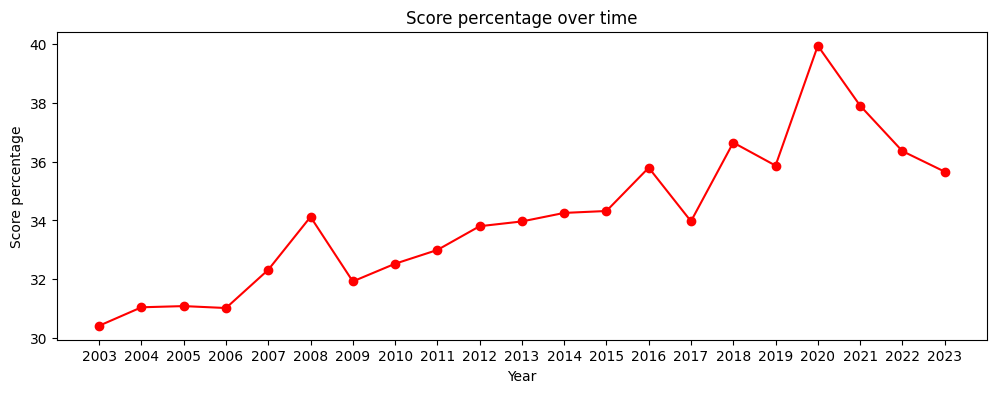

In [38]:
Score_pct = Filtered.groupby('year')['score_pct'].mean()
plt.figure(figsize=(12,4))
plt.plot(Score_pct,color='red',marker='o')
plt.xlabel("Year")
plt.ylabel("Score percentage");
plt.xticks(Score_pct.index);
plt.title("Score percentage over time");


This plot shows that offenses have gotten better at converting their possessions into points over time from 2003 to 2023.
There has also been a decline in the amount of possessions that end with a turnover, as offenses have gotten better at protecting the football.

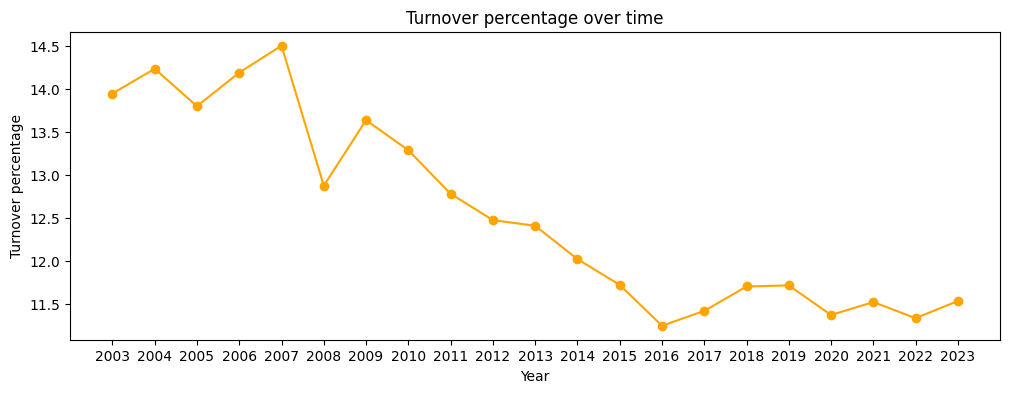

In [39]:
Turnover_percentage = Filtered.groupby('year')['turnover_pct'].mean()
plt.figure(figsize=(12,4))
plt.plot(Turnover_percentage,color='orange',marker='o')
plt.xlabel("Year")
plt.ylabel("Turnover percentage");
plt.xticks(Turnover_percentage.index);
plt.title("Turnover percentage over time");

Points have dramatically risen as the NFL has focused on making it easier to score.

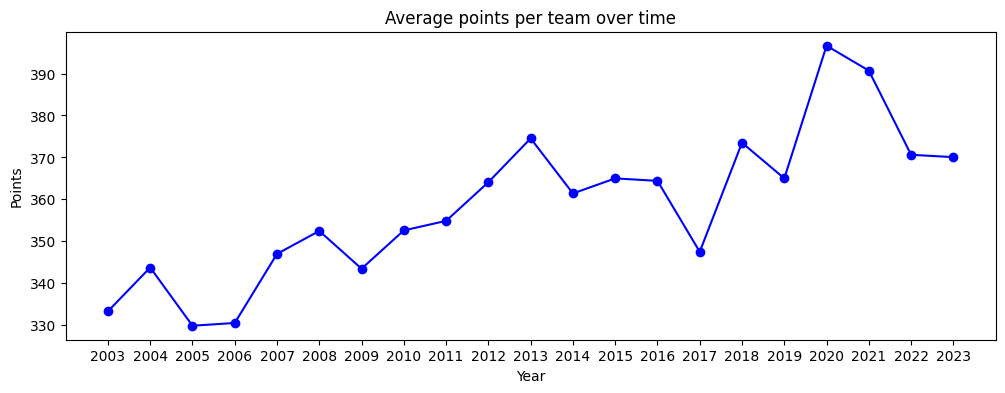

In [40]:
Points = Filtered.groupby('year')['points'].mean()
plt.figure(figsize=(12,4))
plt.plot(Points,color='blue',marker='o')
plt.xlabel("Year")
plt.ylabel("Points")
plt.title("Average points per team over time");
plt.xticks(Points.index);

For this reason I am interested in era adjusted statistics. So for example, lets say that you have team A who scored 25 points per game in the season that they played. Team B also scored 25 points per game in the season that they played. It looks the same. However, in the season that team A played, league average for points scored was 25. This means that team A was a league average team. For team B, the average amount of points scored was 20. This means that their 25 points scored per game was above league average.
The way that I will quantify this is to set 100 as league average. Anything above or below that line is one percent more or less than the average line.
I will use masking properties to create the values for this.

In [20]:
Filtered['Points relative to league average'] = (Filtered['points'] / Filtered.groupby('year')['points'].mean()) * 100
Filtered['Points relative to league average'].sort_values(ascending=False)

year  team                
2007  New England Patriots    169.740634
2013  Denver Broncos          161.802253
2011  Green Bay Packers       157.802043
      New Orleans Saints      154.138781
2012  New England Patriots    152.982577
                                 ...    
2009  Oakland Raiders          57.356019
2010  Carolina Panthers        55.588053
2011  St. Louis Rams           54.385347
2009  St. Louis Rams           50.950778
2006  Oakland Raiders          50.827267
Name: Points relative to league average, Length: 672, dtype: float64

What we can see from this data is that the 2007 New England Patriots have the highest point total adjusting for the average amount of points scored that season. They scored 589 points, which is the second highest in NFL history behind the 2013 Denver Broncos 606. The worse offensive leaguewide environment in 2007 compared to 2013 is why the 2007 Patriots are higher.
The worst team relative to the league environment was the 2006 Raiders, who were very bad and this bad offense was one of the reasons they were the worst team in the NFL that season.
The same thing can be done for score percentage.

In [13]:
Filtered['Score percentage'] = (Filtered['score_pct'] / Filtered.groupby('year')['score_pct'].mean()) * 100
Filtered['Score percentage'].sort_values(ascending=False)

,,Score percentage
year,team,
2007,New England Patriots,163.063237
2011,New Orleans Saints,155.787081
2006,Indianapolis Colts,152.826196
2003,Indianapolis Colts,152.240033
2004,Indianapolis Colts,149.159368
...,...,...
2011,St. Louis Rams,57.283576
2023,New England Patriots,56.642131
2006,Oakland Raiders,53.843829


Three of the top five teams were led by Peyton Manning when he was on the Indianapolis Colts. Makes sense that a team led by one of the greatest players ever would be good at converting drives into points.
You would expect that the teams that turned the ball over a lot would be the teams that are not very good. Teams that are good at holding onto the ball would be pretty good.

In [10]:
Filtered['Turnover percentage relative to league average'] = (Filtered['turnover_pct'] / Filtered.groupby('year')['turnover_pct'].mean()) * 100
Filtered['Turnover percentage relative to league average'].sort_values(ascending=False)

,,Turnover percentage relative to league average
year,team,
2017,Cleveland Browns,183.857729
2006,Oakland Raiders,176.133862
2019,Tampa Bay Buccaneers,172.373333
2018,Tampa Bay Buccaneers,162.306460
2013,New York Giants,161.933535
...,...,...
2011,Green Bay Packers,47.714495
2016,New England Patriots,43.555556
2011,San Francisco 49ers,40.674652


Hilariously, the 2017 Cleveland Browns had the highest number in this category. This team went 0-16 and just generally embarrased themselves on the football field.

Some interesting plots that you can do with this data is the amount of rushing yards vs the number of rush attempts. If a data point is over the line, it is better than expected.

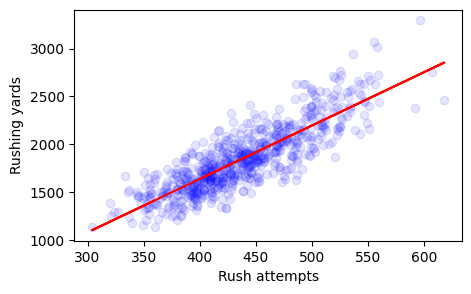

In [52]:
x = Running['rush_att']
y = Running['rush_yds']
m, b = np.polyfit(x,y,1)
plt.figure(figsize=(5,3))
plt.plot(x, y, 'ob', alpha=0.1);
plt.plot(x,(m*x)+b, color='red')
plt.xlabel("Rush attempts")
plt.ylabel("Rushing yards");

This is a scatter plot of all the data points of pass attempts and the passing yards. The linear line of best fit is the relationship between the two variables.

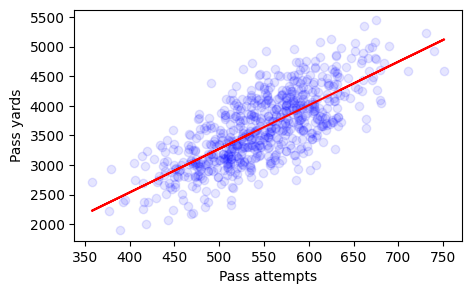

In [53]:
x = Passing['pass_att']
y = Passing['pass_yds']
m, b = np.polyfit(x,y,1)
plt.figure(figsize=(5,3));
plt.plot(x, y, 'ob', alpha=0.1);
plt.plot(x,(m*x)+b,color='red');
plt.xlabel("Pass attempts");
plt.ylabel("Pass yards");

Next a for loop is being set up to create season adjusted statistics for everything in the dataset. This is the dataframe that will be used for manipulations.

In [29]:
f = []
for year, group in Reindexed.groupby('year'):
  year_avg = group.mean()
  relative = (group/year_avg)*100
  f.append(relative)

Adjusted_to_league_average = pd.concat(f).sort_index()

Let's take the data from my favorite team, the Denver Broncos. Going to drop the team as an index because we do not need it after the team has been seperated.

In [30]:
Denver_Broncos = Adjusted_to_league_average.loc[pd.IndexSlice[:, 'Denver Broncos'], :]
Denver_Broncos = Denver_Broncos.droplevel('team')

We can do the same points plot from earlier, but this time using data from the Denver Broncos instead.

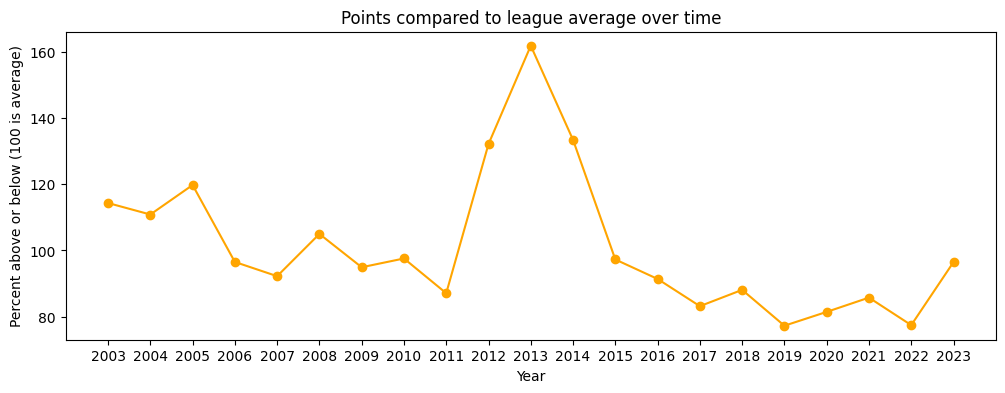

In [42]:
Points = Denver_Broncos['points']
plt.figure(figsize=(12,4))
plt.plot(Points,color='orange',marker='o');
plt.xlabel("Year")
plt.xticks(Points.index)
plt.ylabel("Percent above or below (100 is average)")
plt.title("Points compared to league average over time");


We can create function where you can look up an individual team and their adjusted stats.

In [35]:
def Team_stats(team,year):
  return Adjusted_to_league_average.loc[(year,team), :]

In [36]:
Team_stats('Denver Broncos', 2015)

,2015
,Denver Broncos
wins,150.000000
losses,50.000000
win_loss_perc,149.925037
points,97.260274
points_opp,81.095890
points_diff,inf
mov,inf
g,100.000000
total_yards,100.806380


Credits:
The dataset is from this link on Kaggle:
https://www.kaggle.com/datasets/nickcantalupa/nfl-team-data-2003-2023/data